In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

In [27]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import sklearn.utils as sku

# --------------------------------------------------------
# FILE IDS TO LOAD
# --------------------------------------------------------

file_ids = [
    "00",
    "01",
    "02",
    "03",
    "04",
    "05",
    # "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15",
    "16",
    "17",
    "18"
]

# --------------------------------------------------------
# LOAD ARTICLE MATRICES
# --------------------------------------------------------

data_list = [
    load_npz(f"Data_files/data_articles_{fid}.npz")
    for fid in file_ids
]

# --------------------------------------------------------
# LOAD LABEL FILES
# --------------------------------------------------------

label_list = [
    np.genfromtxt(
        f"Data_files/labels_articles_{fid}.txt",
        delimiter="; ",
        dtype=str,
        encoding="latin1"
    )
    for fid in file_ids
]

# --------------------------------------------------------
# CREATE COMBINED DATASET
# --------------------------------------------------------

data_articles_all = sparse.vstack(data_list, format="csr")

labels_articles_all = np.vstack(label_list)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------
# index = 0 -> date
# index = 1 -> sermon or not
# index = 2 -> article title
# index = 3 -> article topic
# index = 4 -> lix score
# --------------------------------------------------------

# --------------------------------------------------------
# KEEP ONLY TOP X MOST FREQUENT TOPICS
# --------------------------------------------------------

top_x = 10

topics = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(
    topics,
    return_counts=True
)

sorted_indices = np.argsort(topic_counts)[::-1]

valid_topics = unique_topics[
    sorted_indices[:top_x]
]

keep_mask = np.isin(
    topics,
    valid_topics
)

print("Original number of articles:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles:", data_articles_all.shape[0] - keep_mask.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    count = np.sum(topics == topic)
    print(f"{topic}: {count}")

# Apply top-10 filtering
data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# COMBINE / SHUFFLE DATA AFTER TOP-10 FILTERING
# --------------------------------------------------------

data_articles_all, labels_articles_all = sku.shuffle(
    data_articles_all,
    labels_articles_all,
    random_state=5466542
)

# --------------------------------------------------------
# APPLY COLUMN SORTING / FEATURE COMBING
# --------------------------------------------------------

#sort_idx = np.genfromtxt(
    #"txt_files/speeches_sort_idx.txt",
    #delimiter="\n",
    #dtype=int
#)

#data_articles_all = data_articles_all[:, sort_idx][:, :251]

#print("Shape after combing:", data_articles_all.shape)

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, 4].astype(np.float32)

assert data_articles_all.shape[0] == len(lix_scores)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = sparse.hstack(
    [lix_column, data_articles_all],
    format="csr"
)

print("Shape after adding LIX:", data_articles_all.shape)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(with_mean=False)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

# --------------------------------------------------------
# CONVERT TOPICS TO INTEGER LABELS
# --------------------------------------------------------

topic_labels = labels_articles_all[:, 3]

label_encoder = LabelEncoder()

topic_labels_encoded = label_encoder.fit_transform(
    topic_labels
)

# --------------------------------------------------------
# SPLIT DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_articles_all,
    topic_labels_encoded,
    val_size=0.50,
    test_size=0
)

# --------------------------------------------------------
# FINAL OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of labels:", labels_articles_all.shape[0])

print("\nClasses:")
print(label_encoder.classes_)

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample label row:")
print(labels_articles_all[0])

Initial data shape: (804096, 27000)
Initial number of labels: 804096
Original number of articles: 804096
Filtered number of articles: 476750
Removed articles: 327346

Top topics kept:
Danmark: 141387
Internationalt: 137851
Sport: 40451
Kultur: 33781
Politik: 31780
Økonomi: 29522
Fodbold: 24869
Forbrug: 13104
Film og tv: 12261
Debatindlæg: 11744
Shape after adding LIX: (476750, 27001)

Final data shape: (476750, 27001)
Final number of labels: 476750

Classes:
['Danmark' 'Debatindlæg' 'Film og tv' 'Fodbold' 'Forbrug' 'Internationalt'
 'Kultur' 'Politik' 'Sport' 'Økonomi']

Example feature row:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 70 stored elements and shape (1, 27001)>
  Coords	Values
  (0, 0)	4.051688013076845
  (0, 95)	7.903261658089793
  (0, 99)	13.360138323499399
  (0, 403)	10.47073409830068
  (0, 410)	10.884926525017871
  (0, 521)	8.908304953004277
  (0, 600)	3.6170197224861855
  (0, 2714)	5.589678994533574
  (0, 2838)	2.9151529891122174
  (0, 2947)	9.00640

In [28]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

In [29]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [30]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [31]:
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    Layer1 = trial.suggest_int("Layer1", 64, 256)
    Layer2 = trial.suggest_int("Layer2", 32, 128)
    Layer3 = trial.suggest_int("Layer3", 8, 64)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    n_epochs = 3

    input_dim = data_train.shape[1]
    num_classes = len(label_encoder.classes_)

    class OptModel(nn.Module):

        def __init__(self):
            super(OptModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, num_classes)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptModel().to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=sparse_collate
    )

    validation_loader = DataLoader(
        dataset=val_data,
        batch_size=batch_size,
        collate_fn=sparse_collate
    )

    best_validation_loss = float("inf")

    for epoch in range(n_epochs):

        print(f"Trial {trial.number} | Optuna epoch {epoch + 1}/{n_epochs}")

        training_loss, validation_loss = Train(
            model_opt,
            optimizer,
            loss_function,
            train_loader,
            validation_loader,
            device,
            1)

        current_validation_loss = validation_loss[-1]

        best_validation_loss = min(
            best_validation_loss,
            current_validation_loss
        )

        trial.report(current_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

In [32]:
import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, 0].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# TRAIN / VALIDATION SPLIT
# --------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------------------
# DATASET FOR SPARSE MATRICES
# --------------------------------------------------------

class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )


train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)

# --------------------------------------------------------
# MODEL
# --------------------------------------------------------

learning_rate = 1e-4
batch_size = 32
n_epochs = 10
dropout_rate = 0.3

input_dim = X_train.shape[1]

class DateRegressionModel(nn.Module):

    def __init__(self):
        super(DateRegressionModel, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
print("Using device:", device)

model = DateRegressionModel().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

loss_function = nn.MSELoss()

train_loader = DataLoader(
    train_data_reg,
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    val_data_reg,
    batch_size=batch_size,
    shuffle=False
)

# --------------------------------------------------------
# TRAINING LOOP WITH PROGRESS BAR
# --------------------------------------------------------

training_loss = []
validation_loss = []

epoch_bar = tqdm(
    range(n_epochs),
    desc="Training",
    unit="epoch"
)

for epoch in epoch_bar:

    model.train()
    epoch_train_loss = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{n_epochs}",
        leave=False
    )

    for input_batch, truth_batch in train_bar:

        input_batch = input_batch.to(device)
        truth_batch = truth_batch.to(device)

        optimizer.zero_grad()

        predictions = model(input_batch)

        loss = loss_function(
            predictions,
            truth_batch
        )

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        train_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}"
        )

    epoch_train_loss /= len(train_loader)
    training_loss.append(epoch_train_loss)

    model.eval()
    epoch_val_loss = 0

    val_bar = tqdm(
        validation_loader,
        desc=f"Validation {epoch + 1}/{n_epochs}",
        leave=False
    )

    with pt.no_grad():

        for input_batch, truth_batch in val_bar:

            input_batch = input_batch.to(device)
            truth_batch = truth_batch.to(device)

            predictions = model(input_batch)

            loss = loss_function(
                predictions,
                truth_batch
            )

            epoch_val_loss += loss.item()

            val_bar.set_postfix(
                batch_loss=f"{loss.item():.4f}"
            )

    epoch_val_loss /= len(validation_loader)
    validation_loss.append(epoch_val_loss)

    epoch_bar.set_postfix(
        train_loss=f"{epoch_train_loss:.4f}",
        val_loss=f"{epoch_val_loss:.4f}"
    )

print("Training finished.")

# --------------------------------------------------------
# EVALUATE IN REAL YEAR UNITS
# --------------------------------------------------------

model.eval()

all_predictions = []
all_truths = []

print("Generating validation predictions...")

with pt.no_grad():

    for input_batch, truth_batch in tqdm(
        validation_loader,
        desc="Evaluating"
    ):

        input_batch = input_batch.to(device)

        predictions = model(input_batch)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.numpy()
        )

all_predictions = np.array(all_predictions).reshape(-1, 1)
all_truths = np.array(all_truths).reshape(-1, 1)

predicted_years = y_scaler.inverse_transform(
    all_predictions
).ravel()

true_years = y_scaler.inverse_transform(
    all_truths
).ravel()

mae_years = mean_absolute_error(
    true_years,
    predicted_years
)

rmse_years = np.sqrt(
    mean_squared_error(
        true_years,
        predicted_years
    )
)

print("MAE in years:", mae_years)
print("RMSE in years:", rmse_years)

print("MAE in days:", mae_years * 365.25)
print("RMSE in days:", rmse_years * 365.25)

results = pd.DataFrame({
    "True year": true_years,
    "Predicted year": predicted_years,
    "Error (years)": predicted_years - true_years,
    "Error (days)": (predicted_years - true_years) * 365.25
})

results.head(10)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 476750
Using device: cpu


Training:   0%|          | 0/10 [00:00<?, ?epoch/s]

Epoch 1/10:   0%|          | 0/11919 [00:00<?, ?it/s]

Validation 1/10:   0%|          | 0/2980 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/11919 [00:00<?, ?it/s]

...

Validation 10/10:   0%|          | 0/2980 [00:00<?, ?it/s]

Training finished.
Generating validation predictions...


Evaluating:   0%|          | 0/2980 [00:00<?, ?it/s]

MAE in years: 2.018472194671631
RMSE in years: 2.8420703664574365
MAE in days: 737.2469691038132
RMSE in days: 1038.0662013485787


,True year,Predicted year,Error (years),Error (days)
0,2017.113525,2010.980469,-6.133057,-2240.098877
1,2025.086060,2018.789062,-6.296997,-2299.978271
2,2007.549316,2011.530762,3.981445,1454.222900
3,2025.318481,2027.505615,2.187134,798.850586
4,2015.110718,2012.376831,-2.733887,-998.552124
5,2008.810303,2010.308350,1.498047,547.161621
6,2012.746094,2010.646484,-2.099609,-766.882324
7,2007.844238,2015.081543,7.237305,2643.425537
8,2016.235107,2019.429810,3.194702,1166.864990
9,2014.266479,2012.163696,-2.102783,-768.041565


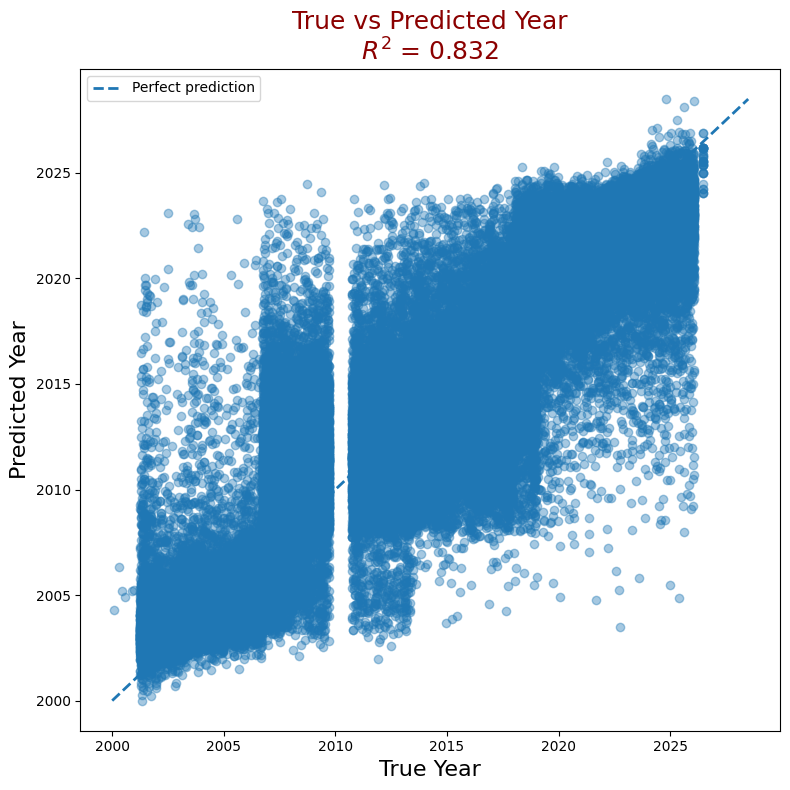

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --------------------------------------------------------
# TRUE VS PREDICTED YEAR
# --------------------------------------------------------

r2 = r2_score(
    true_years,
    predicted_years
)

plt.figure(figsize=(8, 8))

plt.scatter(
    true_years,
    predicted_years,
    alpha=0.4
)

# Perfect prediction line
min_year = min(
    true_years.min(),
    predicted_years.min()
)

max_year = max(
    true_years.max(),
    predicted_years.max()
)

plt.plot(
    [min_year, max_year],
    [min_year, max_year],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel(
    "True Year",
    fontsize=16
)

plt.ylabel(
    "Predicted Year",
    fontsize=16
)

plt.title(
    f"True vs Predicted Year\n$R^2$ = {r2:.3f}",
    fontsize=18,
    color="darkred"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "Regression_ArticleDate_TrueVsPredicted.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

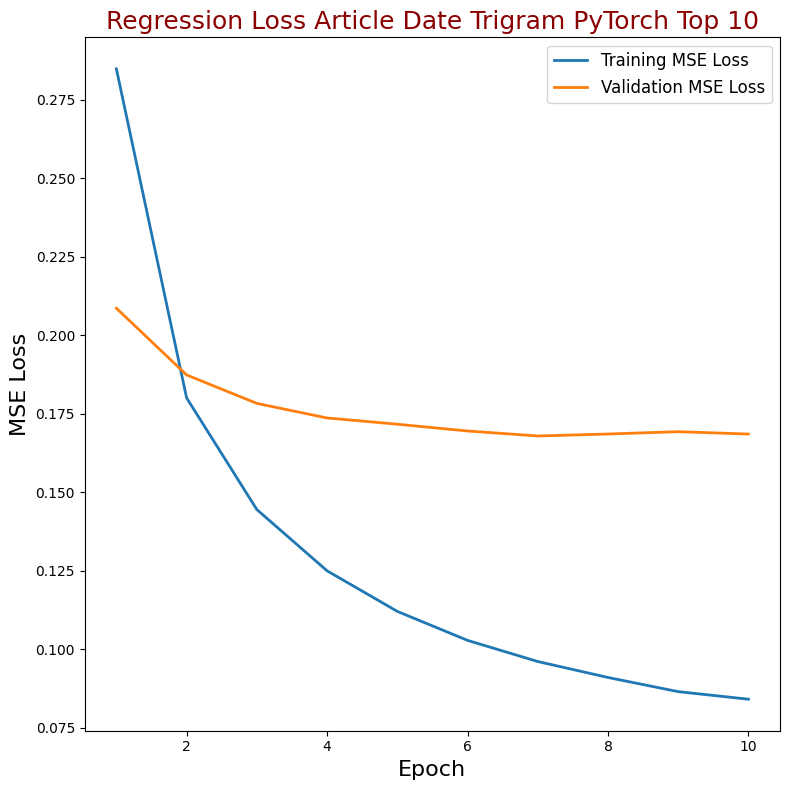

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# PLOT REGRESSION LOSS CURVE
# --------------------------------------------------------

epochs = np.arange(1, len(training_loss) + 1)

plt.figure(figsize=(8, 8))

plt.plot(
    epochs,
    training_loss,
    linewidth=2,
    label="Training MSE Loss"
)

plt.plot(
    epochs,
    validation_loss,
    linewidth=2,
    label="Validation MSE Loss"
)

plt.xlabel("Epoch", fontsize=16)
plt.ylabel("MSE Loss", fontsize=16)

plt.title(
    "Regression Loss Article Date Trigram PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig(
    "Regression_Loss_ArticleDate_TrigramPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()